<a href="https://colab.research.google.com/github/KaueOPG/DCC008---Calculo-Numerico/blob/main/Trabalho_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabalho Final - Solução de Sistemas de Equações Lineares


#Grupo:
1 - Kauê Oliveira Paraízo Garcia - 202265517B

2 - João Pedro Barbosa Coelho - 202369012D

#Pré-requisitos

As seguintes bibliotecas foram instaladas e importadas:

In [ ]:
import numpy as np
from numpy import exp
from numpy import cos
from numpy import sin
from numpy import pi
from numpy.linalg import solve
from numpy import linspace

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot

#Solução de Sistemas de Equações Lineares

Definição do método de Newton-Raphson, que recebe a função F, a matriz jacobiana J, a tolerancia E e o numero máximo de interações kmax:

In [ ]:
def Newton2(J, F, x, kmax, e):
  erro=np.zeros(kmax)
  for k in range(kmax):
    x= x-solve(J(x),F(x))
    erro[k]=max(abs(F(x)))
    if erro[k] < e:
      break
  erro=erro[0:k]
  K=np.arange(k)
  return x, erro, K

Testes e resultados:

1) Encontro entre dois círculos:

$x^2+y^2=1$

$(x-1)^2+y^2=1$

Definição das funções dos círculos em F:

In [ ]:
def F(x):
  f=np.zeros(2)
  f[0]=x[0]**2+x[1]**2-1
  f[1]=(x[0]-1)**2+x[1]**2-1
  return f

Definição da matriz jacobiana J:

In [ ]:
def J(x):
  j=np.zeros((2,2))
  j[0, 0]=2*x[0]
  j[0, 1]=2*x[1]
  j[1, 0]=2*(x[0]-1)
  j[1, 1]=2*x[1]
  return j

In [ ]:
x=[0,-1]
kmax=20
e = 0.000001
x, erro, K= Newton2(J, F, x, kmax, e)
print('(x, y) = (', x[0],',' , x[1], ')')
print('Erro: ', erro[K.size-1])
print('Número de interações:', K[K.size-1]+1)

(x, y) = ( 0.5 , -0.8660254050073638 )
Erro:  7.971938775508391e-05
Número de interações: 3


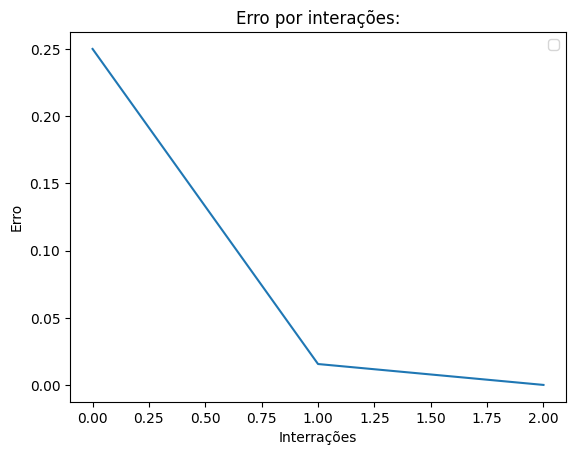

In [ ]:
plt.plot(K, erro)
plt.title('Erro por interações:')
plt.xlabel('Interrações')
plt.ylabel('Erro')
plt.legend()
plt.show()

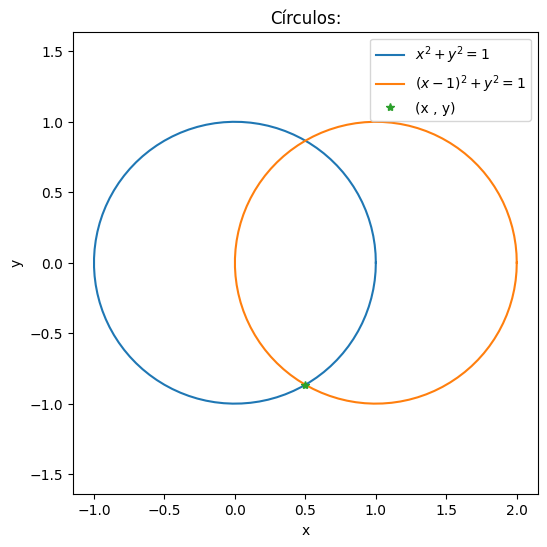

In [ ]:
theta = np.linspace(0, 2*np.pi, 100)
f11 = 1 + np.cos(theta)
f00 = np.cos(theta)
yy = np.sin(theta)
plt.figure(figsize=(6, 6))
plt.plot(f00, yy, label=r'$x^2 + y^2 = 1$')
plt.plot(f11, yy, label=r'$(x-1)^2 + y^2 = 1$')
plt.plot(x[0], x[1], '*', label = '(x , y)')
plt.title('Círculos:')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.show()

2) Resolver uma equação cúbica $x^3-6x^2+11x-6$ usando fórmulas de Vieta:

$x + y + z = 6$

$xy + xz + yz = 11$

$xyz= 6$

Definindo as funções acima:

In [ ]:
def F(x):
  f=np.zeros(3)
  f[0]=x[0]+x[1]+x[2]-6
  f[1]=x[0]*x[1]+x[0]*x[2]+x[1]*x[2]-11
  f[2]=x[0]*x[1]*x[2]-6
  return f

Definindo a matrix jacobiana:

In [ ]:
def J(x):
  j=np.zeros((3,3))
  j[0, 0]=1
  j[0, 1]=1
  j[0, 2]=1
  j[1, 0]=x[1]+x[2]
  j[1, 1]=x[0]+x[2]
  j[1, 2]=x[0]+x[1]
  j[2, 0]=x[1]*x[2]
  j[2, 1]=x[0]*x[2]
  j[2, 2]=x[0]*x[1]
  return j

In [ ]:
x=[1.5,2.5,3.5]
kmax=50
x, erro, K= Newton2(J, F, x, kmax, e)
print('(x_1, x_2 , x_3) = (', x[0],',', x[1],',', x[2],')')
print('Erro: ', erro[K.size-1])
print('Número de interações:', K[K.size-1]+1)

(x_1, x_2 , x_3) = ( 0.9999999999997765 , 1.9999999999889753 , 3.000000000011248 )
Erro:  3.1981807175895938e-06
Número de interações: 5


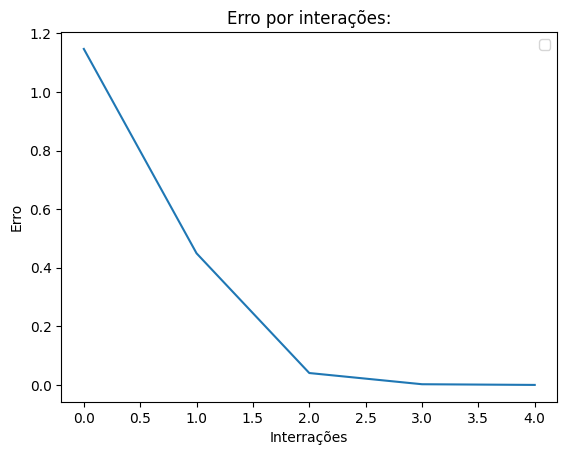

In [ ]:
plt.plot(K, erro)
plt.title('Erro por interações:')
plt.xlabel('Interrações')
plt.ylabel('Erro')
plt.legend()
plt.show()

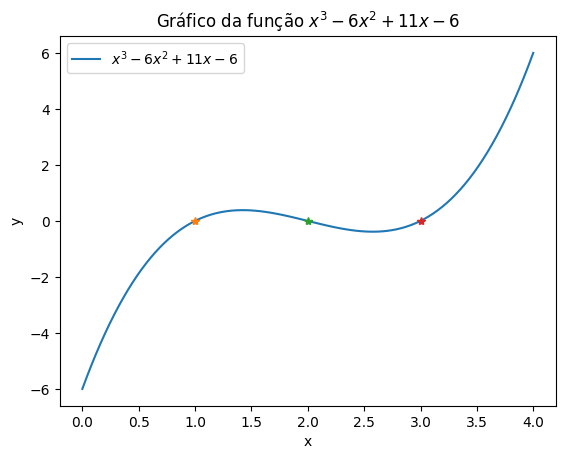

In [ ]:
x22= np.linspace(0, 4, 100)
y22 = x22**3 - 6*x22**2 + 11*x22 - 6
plt.plot(x22, y22, label=r'$x^3 - 6x^2 + 11x - 6$')
plt.plot(x[0], 0, '*')
plt.plot(x[1], 0, '*')
plt.plot(x[2], 0,'*')
plt.title('Gráfico da função $x^3 - 6x^2 + 11x - 6$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#Problema de Valor de Contorno

Definindo a função G:

In [ ]:
def g(x,lamb):
  return (pi**2)*sin(pi*x)-lamb*exp(sin(pi*x))

Definindo as funções F:

In [ ]:
def F(x, N, lamb):
  h=1/N
  f=np.zeros(N+1)
  f[0]=0
  f[N]=0
  for k in range(N-1):
    f[k+1] =(-x[k+2]+2*x[k+1]-x[k])/h**2-lamb*exp(x[k])-g(k*h, lamb)
  return f

Definindo a matriz Jacobiana:

In [ ]:
def J(x, N, lamb):
  h=1/N
  j=np.zeros((N+1,N+1))
  j[0,0]=1
  j[N,N]=1
  for k in range(N-1):
    j[k+1,k] = -1/h**2-lamb*exp(x[k])
    j[k+1,k+1] = 2/h**2
    j[k+1,k+2] = -1/h**2
  return j

Definindo a função do método de Newton:

In [ ]:
def Newton(N, lamb, kmax, e):
  x=np.zeros(N+1)
  for k in range(kmax):
    x= x-solve(J(x, N, lamb),F(x, N, lamb))
    if max(abs(F(x, N, lamb)))<e:
      break
  error=erro[0:k]
  K=np.arange(k)
  return x, error, K

1) Teste


N: 10
erro: 0.04059854597455548
k: 3.0
N: 50
erro: 0.04059854597455548
k: 3.0
N: 100
erro: 0.04059854597455548
k: 3.0


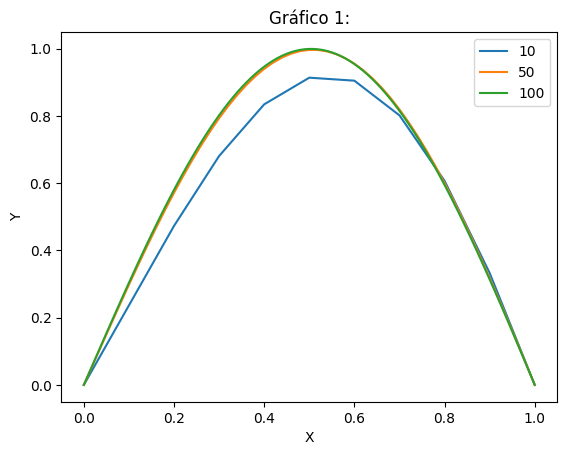

In [ ]:
N=[10, 50, 100]
lamb=2
kmax=100
e = 0.0000001
kfinal = np.zeros(3)
errorfinal = np.zeros(3)
for i in range(3):
  titlen = str(N[i])
  x, error, k = Newton(N[i], lamb, kmax, e)
  kfinal[i]= k.size
  errorfinal[i] = np.min(error)
  t=np.arange(0,N[i]+1,1)/N[i]
  plt.plot(t,x, label= titlen)
  plt.title('Gráfico 1:')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.legend()
for i in range(3):
  print('N:', N[i])
  print('erro:', errorfinal[i])
  print('k:', kfinal[i])

2) Teste

lamb e N: 1 10
erro: 0.04059854597455548
k: 3.0
lamb e N: 1 50
erro: 0.04059854597455548
k: 3.0
lamb e N: 1 100
erro: 0.04059854597455548
k: 3.0


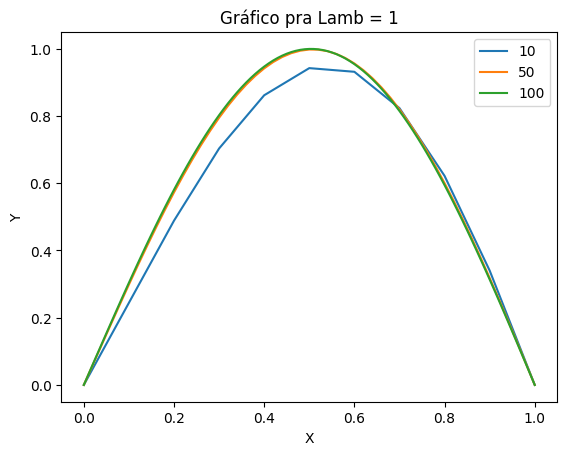

lamb e N: 2 10
erro: 0.04059854597455548
k: 3.0
lamb e N: 2 50
erro: 0.04059854597455548
k: 3.0
lamb e N: 2 100
erro: 0.04059854597455548
k: 3.0


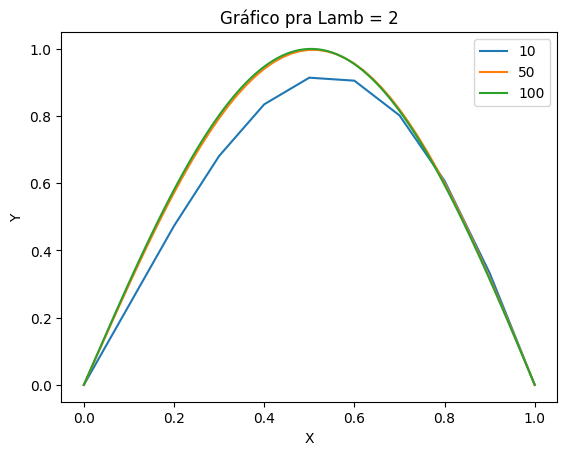

lamb e N: 3 10
erro: 0.04059854597455548
k: 3.0
lamb e N: 3 50
erro: 0.002353563203910447
k: 4.0
lamb e N: 3 100
erro: 0.002353563203910447
k: 4.0


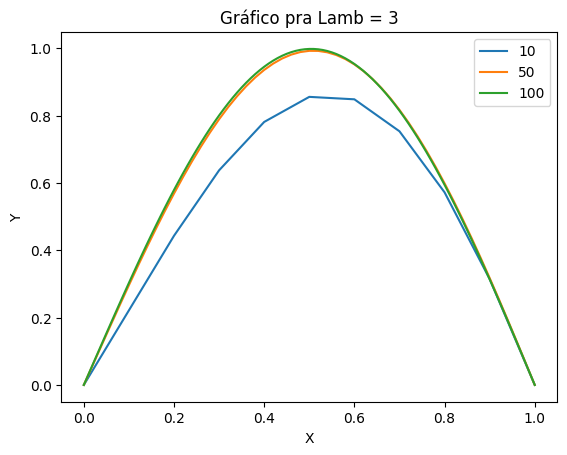

lamb e N: 4 10
erro: 0.002353563203910447
k: 4.0
lamb e N: 4 50
erro: 3.1981807175895938e-06
k: 6.0
lamb e N: 4 100
erro: 3.1981807175895938e-06
k: 6.0


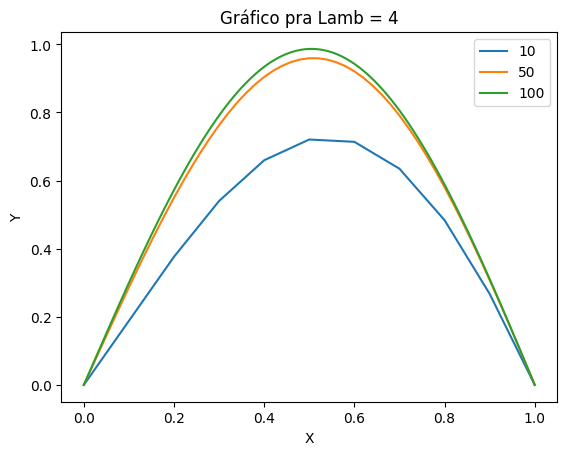

lamb e N: 5 10
erro: 0.04059854597455548
k: 3.0
lamb e N: 5 50
erro: 0.002353563203910447
k: 4.0
lamb e N: 5 100
erro: 0.002353563203910447
k: 4.0


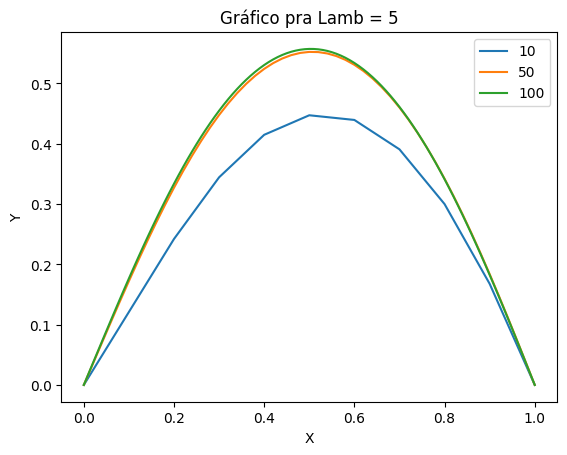

lamb e N: 6 10
erro: 0.4492904392219881
k: 2.0
lamb e N: 6 50
erro: 0.4492904392219881
k: 2.0
lamb e N: 6 100
erro: 0.4492904392219881
k: 2.0


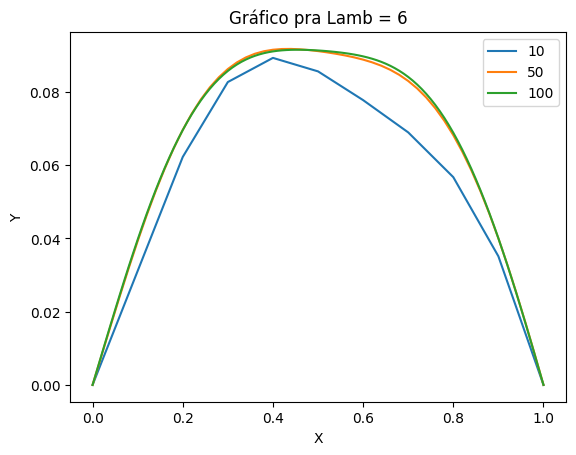

In [ ]:
N=[10, 50, 100]
kmax=100
kfinal = np.zeros(6)
errorfinal = np.zeros(6)
for lamb in range(1,7):
  for i in range(3):
    titlen = str(N[i])
    x,error, k=Newton(N[i], lamb , kmax, e)
    kfinal[lamb-1]= k.size
    errorfinal[lamb-1] = np.min(error)
    t=np.arange(0,N[i]+1,1)/N[i]
    plt.plot(t,x, label=str(N[i]))
    plt.title('Gráfico pra Lamb = ' + str(lamb))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    #visualizar erro e k
    print('lamb e N:', lamb, N[i])
    print('erro:', errorfinal[lamb-1])
    print('k:', kfinal[lamb-1])
  plt.show()

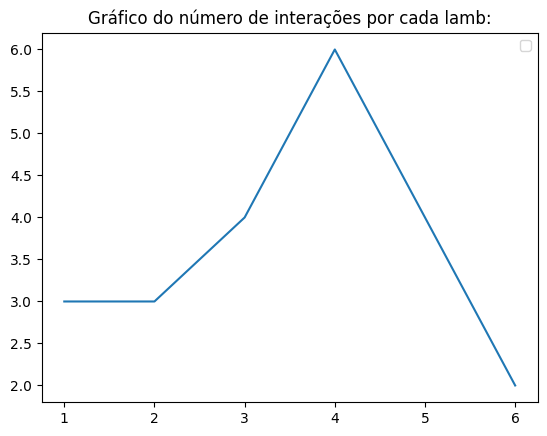

In [ ]:
lamb = [1,2,3,4,5,6]
plt.plot(lamb, kfinal)
plt.title('Gráfico do número de interações por cada lamb:')
plt.legend()
plt.show()